In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Configuration
# Load data
IMG_DIR = "./crops/"  # Replace with the image directory
MASK_DIR = "./final_mask/"    # Replace with the mask directory
IMG_SIZE = (100, 100)
BATCH_SIZE = 8
LR = 1e-3
EPOCHS = 10
TEST_SPLIT = 0.2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Dataset Definition
class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.image_filenames = sorted(os.listdir(img_dir))
        self.mask_filenames = sorted(os.listdir(mask_dir))
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_filenames[idx])
        
        image = Image.open(img_path).convert("L")  # Grayscale
        mask = Image.open(mask_path).convert("L")  # Binary mask
        
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
            mask = (mask > 0.5).float()  # Convert to binary (0,1)
        
        return image, mask

# Transforms
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

# Load Dataset
dataset =  SegmentationDataset(IMG_DIR, MASK_DIR, transform)
train_size = int((1 - TEST_SPLIT) * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [3]:
next(iter(train_loader))

[tensor([[[[0.1255, 0.1294, 0.1373,  ..., 0.2549, 0.2157, 0.2196],
           [0.1373, 0.1294, 0.1412,  ..., 0.2118, 0.2196, 0.2235],
           [0.1451, 0.1412, 0.1412,  ..., 0.2118, 0.2196, 0.2235],
           ...,
           [0.2000, 0.2000, 0.2078,  ..., 0.2157, 0.2275, 0.2431],
           [0.2118, 0.2078, 0.2157,  ..., 0.2196, 0.2235, 0.2353],
           [0.2039, 0.2039, 0.2118,  ..., 0.2196, 0.2275, 0.2196]]],
 
 
         [[[0.2157, 0.2118, 0.2157,  ..., 0.2196, 0.2196, 0.2235],
           [0.2235, 0.2196, 0.2078,  ..., 0.2196, 0.2157, 0.2157],
           [0.2157, 0.2196, 0.2157,  ..., 0.2196, 0.2039, 0.2157],
           ...,
           [0.2118, 0.2078, 0.2039,  ..., 0.2078, 0.2157, 0.2196],
           [0.2078, 0.2078, 0.2157,  ..., 0.2078, 0.2039, 0.2118],
           [0.2118, 0.2157, 0.2078,  ..., 0.2118, 0.2118, 0.2039]]],
 
 
         [[[0.2510, 0.2706, 0.2431,  ..., 0.2196, 0.2235, 0.2275],
           [0.2275, 0.2627, 0.2471,  ..., 0.2196, 0.2353, 0.2196],
           [0.2314

In [4]:
# Define a Simple FCN Model
class SimpleFCN(nn.Module):
    def __init__(self):
        super(SimpleFCN, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 1, 3, padding=1), nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [5]:
# Define a Smaller Model
class SmallUNet(nn.Module):
    def __init__(self):
        super(SmallUNet, self).__init__()
        
        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU()
            )
        
        self.encoder1 = conv_block(1, 32)
        self.encoder2 = conv_block(32, 64)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.bottleneck = conv_block(64, 128)
        
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder2 = conv_block(128, 64)
        
        self.upconv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.decoder1 = conv_block(64, 32)
        
        self.final_conv = nn.Conv2d(32, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        
        bottleneck = self.bottleneck(self.pool(enc2))
        
        dec2 = self.decoder2(torch.cat([self.upconv2(bottleneck), enc2], dim=1))
        dec1 = self.decoder1(torch.cat([self.upconv1(dec2), enc1], dim=1))
        
        return self.sigmoid(self.final_conv(dec1))

In [6]:
# Initialize Model, Loss, and Optimizer
model = SmallUNet().to(DEVICE)
criterion = nn.BCELoss()


In [7]:

optimizer = optim.Adam(model.parameters(), lr=LR)


In [8]:
# Count Parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {num_params}")

Total Trainable Parameters: 465953


In [9]:
# Training Loop
def train():
    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(train_loader):.4f}")

# Run Training
train()


Epoch 1/10, Loss: 0.3166
Epoch 2/10, Loss: 0.3143
Epoch 3/10, Loss: 0.3143
Epoch 4/10, Loss: 0.3143
Epoch 5/10, Loss: 0.3143
Epoch 6/10, Loss: 0.3143
Epoch 7/10, Loss: 0.3143
Epoch 8/10, Loss: 0.3143
Epoch 9/10, Loss: 0.3143
Epoch 10/10, Loss: 0.3143


In [10]:
model = torch.load('best_Unet_crack.pt')

C:\Users\Windows\AppData\Local\Temp\ipykernel_14652\965467263.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('best_Unet_crack.pt')


FileNotFoundError: [Errno 2] No such file or directory: 'best_Unet_crack.pt'

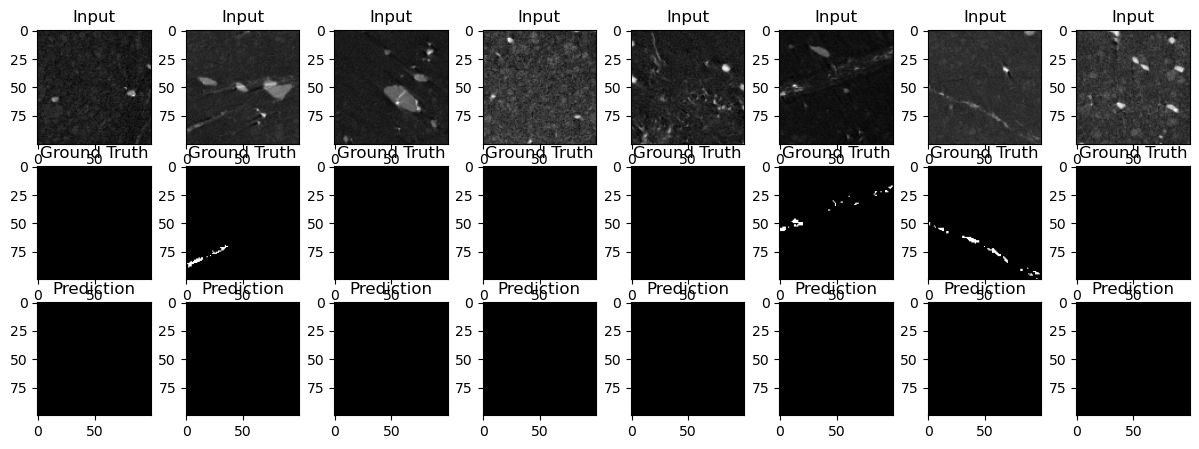

In [11]:

# Evaluation Function
def visualize_predictions():
    model.eval()
    images, masks = next(iter(test_loader))
    images, masks = images.to(DEVICE), masks.to(DEVICE)
    with torch.no_grad():
        outputs = model(images)
    
    fig, axs = plt.subplots(3, BATCH_SIZE, figsize=(15, 5))
    for i in range(BATCH_SIZE):
        axs[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
        axs[0, i].set_title("Input")
        axs[1, i].imshow(masks[i].cpu().squeeze(), cmap='gray')
        axs[1, i].set_title("Ground Truth")
        axs[2, i].imshow(outputs[i].cpu().squeeze(), cmap='gray')
        axs[2, i].set_title("Prediction")
    plt.show()

# Show results
visualize_predictions()


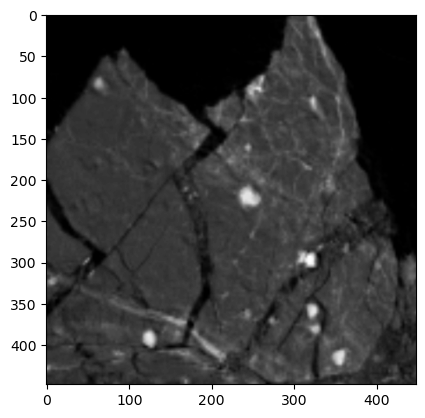

In [15]:
image = Image.open('./1.png').convert("L")
plt.imshow(image, cmap='gray')

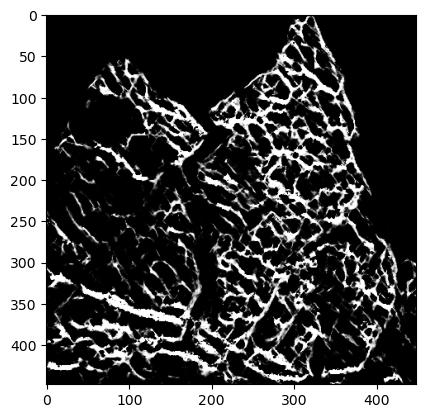

In [16]:
plt.imshow(model(torch.Tensor(np.array(image)/255.0).unsqueeze(0).unsqueeze(0).to(DEVICE)).detach().cpu().squeeze(), cmap='gray')

In [104]:
# torch.save(model, 'best_Unet_crack.pt')